In [1]:
import random
import os
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
import warnings
from sklearn.metrics import r2_score 

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
seed_everything(42)


========================= CV Training XGBoost: Revenue (No Leakage) =========================
Fold 1 | RMSE Log: 0.3059 | MAE Actual:   1054212.76 | RMSE Actual:   1545327.46 | R2:  0.6318
Fold 2 | RMSE Log: 0.2508 | MAE Actual:   1045128.66 | RMSE Actual:   1471155.01 | R2:  0.7580
Fold 3 | RMSE Log: 0.2629 | MAE Actual:   1037075.67 | RMSE Actual:   1452301.53 | R2:  0.7674
Fold 4 | RMSE Log: 0.3085 | MAE Actual:    955111.52 | RMSE Actual:   1297215.90 | R2:  0.8088
Fold 5 | RMSE Log: 0.5143 | MAE Actual:   1769397.74 | RMSE Actual:   2352303.26 | R2: -0.9048
Fold 6 | RMSE Log: 0.2541 | MAE Actual:    552637.20 | RMSE Actual:    797475.10 | R2:  0.7709
Fold 7 | RMSE Log: 0.2767 | MAE Actual:    571972.15 | RMSE Actual:    802149.72 | R2:  0.7487

========================= CV Training XGBoost: COGS (No Leakage) =========================
Fold 1 | RMSE Log: 0.2833 | MAE Actual:    809962.46 | RMSE Actual:   1174306.73 | R2:  0.6905
Fold 2 | RMSE Log: 0.2296 | MAE Actual:    829912.19 

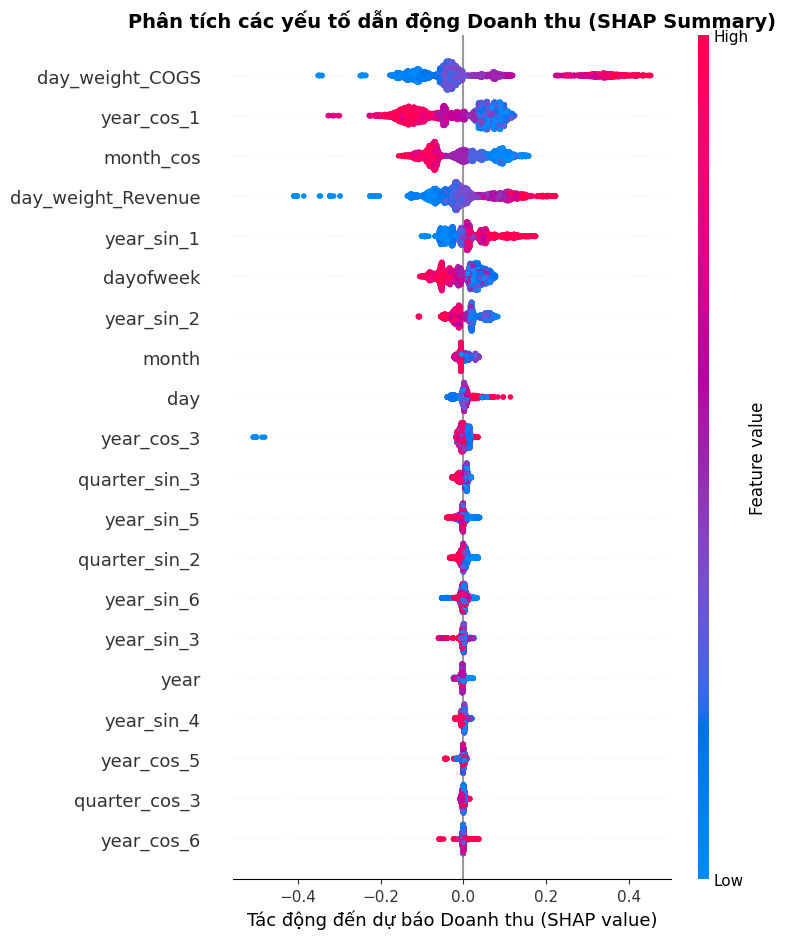

Danh sách features đã sử dụng: ['month', 'day', 'day_weight_Revenue', 'day_weight_COGS', 'year', 'dayofweek', 'quarter', 'month_sin', 'month_cos', 'year_sin_1', 'year_cos_1', 'year_sin_2', 'year_cos_2', 'year_sin_3', 'year_cos_3', 'year_sin_4', 'year_cos_4', 'year_sin_5', 'year_cos_5', 'year_sin_6', 'year_cos_6', 'quarter_sin_1', 'quarter_cos_1', 'quarter_sin_2', 'quarter_cos_2', 'quarter_sin_3', 'quarter_cos_3']
Đã lưu biểu đồ thành công!

==================== HOÀN TẤT XUẤT FILE ====================
File đã lưu: submission.csv
Số lượng dòng: 548

Xem trước nội dung file:
         Date      Revenue         COGS
0  2023-01-01  3719236.750  3261941.000
1  2023-01-02  1681059.250  1363345.625
2  2023-01-03  1514166.375  1238223.625
3  2023-01-04  1465523.000  1167953.125
4  2023-01-05  1584325.625  1301327.875
✅ Kiểm tra logic: Hợp lệ (COGS <= Revenue).


In [2]:
# Thêm dòng này ở đầu file

warnings.filterwarnings('ignore')

# =================================
# 1.LOAD DỮ LIỆU
# =================================
DATA_DIR = 'datathon-2026-round-1/'
TRAIN_FILE = DATA_DIR + 'sales.csv'
TEST_FILE  = DATA_DIR + 'sample_submission.csv'

train_df = pd.read_csv(TRAIN_FILE, parse_dates=['Date'])
train_df = train_df.sort_values('Date').reset_index(drop=True)
test_df  = pd.read_csv(TEST_FILE,  parse_dates=['Date'])

import pandas as pd
import numpy as np

#============================
# 2.FEATURE ENGINEERING
#===========================

def add_fourier_features(df, target_period, n_order, prefix):
    day_in_cycle = df['Date'].dt.dayofyear
    for i in range(1, n_order + 1):
        df[f'{prefix}_sin_{i}'] = np.sin(2 * i * np.pi * day_in_cycle / target_period)
        df[f'{prefix}_cos_{i}'] = np.cos(2 * i * np.pi * day_in_cycle / target_period)
    return df

def create_feature_trained(df_train, target_cols, df_test=None):
    if isinstance(target_cols, str):
        target_cols = [target_cols]

    #insight 1: tuy chia sẻ feature mùa vụ theo tháng, nhưng pattern theo ngày của từng tháng vẫn có sự khác biệt 
    def approximate_monthly_weights(day_series):
        """
        Thực hiện xấp xỉ động cho trọng số trong 1 tháng:
        - 3 ngày đầu & 3 ngày cuối: Bậc 2
        - Các ngày ở giữa: Tuyến tính
        """
        days = day_series.index.values
        weights = day_series.values
        n = len(days)
        new_w = np.zeros(n)
        
        if n < 7: return day_series # Tránh lỗi nếu tháng quá ngắn
        
        # 3 ngày đầu: Bậc 2
        idx_start = [0, 1, 2]
        p_start = np.polyfit(days[idx_start], weights[idx_start], 2)
        new_w[idx_start] = np.polyval(p_start, days[idx_start])
        
        # 3 ngày cuối: Bậc 2
        idx_end = [n-3, n-2, n-1]
        p_end = np.polyfit(days[idx_end], weights[idx_end], 2)
        new_w[idx_end] = np.polyval(p_end, days[idx_end])
        
        # Những ngày ở giữa: Tuyến tính
        idx_mid = np.arange(3, n-3)
        p_mid = np.polyfit(days[idx_mid], weights[idx_mid], 1)
        new_w[idx_mid] = np.polyval(p_mid, days[idx_mid])
        
        # Hậu xử lý: Không âm và chuẩn hóa tổng = 1
        new_w = np.maximum(new_w, 0)
        if new_w.sum() > 0:
            new_w = new_w / new_w.sum()
        return pd.Series(new_w, index=days)

    def get_weights_map(df, cols):
        temp = df.copy()
        temp['day'] = temp['Date'].dt.day
        temp['month'] = temp['Date'].dt.month
        temp['year'] = temp['Date'].dt.year
        
        all_weights_dfs = []
        
        for col in cols:
            m_sum = temp.groupby(['year', 'month'])[col].transform('sum')
            temp['raw_w'] = np.where(m_sum != 0, temp[col] / m_sum, 0)
            raw_map = temp.groupby(['month', 'day'])['raw_w'].mean().reset_index()
            dynamic_list = []
            for m in range(1, 13):
                m_data = raw_map[raw_map['month'] == m].sort_values('day')
                if not m_data.empty:
                    smoothed_values = approximate_monthly_weights(m_data.set_index('day')['raw_w'])
                    
                    df_m = smoothed_values.reset_index()
                    df_m.columns = ['day', f'day_weight_{col}']
                    df_m['month'] = m
                    dynamic_list.append(df_m)
            
            all_weights_dfs.append(pd.concat(dynamic_list))
        
        # Merge các bảng weights của các target khác nhau
        final_weights = all_weights_dfs[0]
        for i in range(1, len(all_weights_dfs)):
            final_weights = final_weights.merge(all_weights_dfs[i], on=['month', 'day'], how='outer')
            
        return final_weights

    weights_combined_map = get_weights_map(df_train, target_cols)

    def apply_feature(df, weights_map):
        df = df.copy()
        df['month'] = df['Date'].dt.month
        df['day'] = df['Date'].dt.day
        
        # Merge trọng số động
        df = df.merge(weights_map, on=['month', 'day'], how='left')
        
        for col in target_cols:
            w_col = f'day_weight_{col}'
            df[w_col] = df[w_col].fillna(df[w_col].mean())
        
        df['year'] = df['Date'].dt.year
        df['dayofweek'] = df['Date'].dt.dayofweek
        df['quarter'] = df['Date'].dt.quarter

        #Insight 2: cogs, revenue có tính mùa vụ theo tháng, quý, năm
        df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12.0)
        df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12.0)
        df = add_fourier_features(df, target_period=365.25, n_order=6, prefix='year')
        df = add_fourier_features(df, target_period=365.25/4, n_order=3, prefix='quarter')
        
        return df

    # Thực thi
    train_processed = apply_feature(df_train, weights_combined_map)
    if df_test is not None:
        test_processed = apply_feature(df_test, weights_combined_map)
        return train_processed, test_processed
    
    return train_processed

from sklearn.metrics import mean_absolute_error, mean_squared_error

#===============================
#3. Huấn luyện mô hình
#==============================


train_df = train_df.sort_values('Date').reset_index(drop=True)
targets = ['Revenue', 'COGS']
n_splits = 7
tscv = TimeSeriesSplit(n_splits=n_splits)

XGB_PARAMS = dict(
    n_estimators     = 1000,
    learning_rate    = 0.02,
    max_depth        = 6,
    subsample        = 0.9,
    colsample_bytree = 0.9,
    random_state     = 42,
    tree_method      = 'hist',
    early_stopping_rounds = 100,
    eval_metric      = 'rmse',
    verbosity        = 0
)

LGB_PARAMS = {
    'n_estimators': 1000,
    'learning_rate': 0.02,
    'importance_type': 'gain',
    'verbosity': -1,
    'random_state': 42
}

all_models = {target: [] for target in targets}

# --- 3. TRAINING VỚI CV VÀ FEATURE ENGINEERING TRONG FOLD ---
for target in targets:
    print(f"\n{'='*25} CV Training XGBoost: {target} (No Leakage) {'='*25}")
    
    for fold, (train_idx, val_idx) in enumerate(tscv.split(train_df)):
        # Tách dữ liệu thô để tránh leakage
        df_tr_raw = train_df.iloc[train_idx].copy()
        df_val_raw = train_df.iloc[val_idx].copy()
        
        # FEATURE ENGINEERING RIÊNG CHO MỖI FOLD
        X_tr, X_val_fold = create_feature_trained(df_tr_raw, targets, df_val_raw)
        ignored_cols = targets + ['Date']
        features = [c for c in X_tr.columns if c not in ignored_cols]
        
        # Target transformation
        y_tr = np.log1p(X_tr[target])
        y_val_log = np.log1p(X_val_fold[target])
        
        # Huấn luyện mô hình
        model = XGBRegressor(**XGB_PARAMS)
        model.fit(
            X_tr[features], y_tr,
            eval_set=[(X_val_fold[features], y_val_log)],
            verbose=False 
        )
        
        all_models[target].append(model)
        # 1. RMSE Log (từ model)
        rmse_log = model.best_score
        
        # 2. MAE thực tế (Inverse transform log1p -> expm1)
        y_val_true = X_val_fold[target].values
        y_val_pred_log = model.predict(X_val_fold[features])
        y_val_pred_actual = np.expm1(y_val_pred_log)
        
        mae_actual = mean_absolute_error(y_val_true, y_val_pred_actual)
        rmse_actual = np.sqrt(mean_squared_error(y_val_true, y_val_pred_actual))
        r2_actual = r2_score(y_val_true, y_val_pred_actual) # Thêm dòng này

        print(f"Fold {fold+1} | RMSE Log: {rmse_log:.4f} | MAE Actual: {mae_actual:12.2f} | RMSE Actual: {rmse_actual:12.2f} | R2: {r2_actual:7.4f}")

print("\n✅ Đã hoàn thành huấn luyện và kiểm tra chỉ số MAE thực tế.")

#=================================
#4. Dự báo trên tập test
#================================
print("\n--- ĐANG THỰC HIỆN ENSEMBLE DỰ BÁO ---")

# Tạo feature dựa trên toàn bộ dữ liệu train để dự báo test
X_train_final, X_test_final = create_feature_trained(train_df, targets, test_df)
final_features = [c for c in X_train_final.columns if c not in ignored_cols]

# Ensemble Averaging (Averaging in Log space then expm1)
test_rev_pred = np.expm1(np.mean(
    [m.predict(X_test_final[final_features]) for m in all_models['Revenue']], 
    axis=0
))

test_cogs_pred = np.expm1(np.mean(
    [m.predict(X_test_final[final_features]) for m in all_models['COGS']], 
    axis=0
))

test_rev_pred = np.maximum(0, test_rev_pred)
test_cogs_pred = np.maximum(0, test_cogs_pred)
test_cogs_pred = np.minimum(test_cogs_pred, test_rev_pred)


#============================================================
#5. Biểu diễn feature importance, yếu tố dẫn động doanh thu
#============================================================

import shap
import matplotlib.pyplot as plt

print("--- TẠO SHAP SUMMARY PLOT CHO REVENUE ---")

if 'all_models' in locals() and 'Revenue' in all_models:
    target_model = all_models['Revenue'][0] 
else:
    print("Lỗi: Biến 'all_models' không tồn tại. Hãy chắc chắn bạn đã chạy bước huấn luyện.")
    # Dừng chạy nếu không có model
    raise NameError("all_models is not defined")

try:
    features_used = target_model.get_booster().feature_names
except:
    features_used = target_model.feature_name_

explainer = shap.TreeExplainer(target_model)
X_shap = X_train_final[features_used]
shap_values = explainer.shap_values(X_shap)

# 5. Vẽ đồ thị
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_shap, show=False)

plt.title("Phân tích các yếu tố dẫn động Doanh thu (SHAP Summary)", fontweight='bold', fontsize=14)
plt.xlabel("Tác động đến dự báo Doanh thu (SHAP value)")
plt.tight_layout()

# 6. Lưu kết quả
plt.savefig('shap_revenue_drivers.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Danh sách features đã sử dụng: {features_used}")
print("Đã lưu biểu đồ thành công!")

#=====================================
# --- 6. TẠO FILE SUBMISSION ---
#=====================================


# Tạo DataFrame kết quả
# Lưu ý: test_df cần có cùng số dòng với kết quả dự báo
submission = pd.DataFrame({
    'Date': test_df['Date'],
    'Revenue': test_rev_pred,
    'COGS': test_cogs_pred
})

# 1. Định dạng ngày tháng thành YYYY-MM-DD
submission['Date'] = pd.to_datetime(submission['Date']).dt.strftime('%Y-%m-%d')
submission['Revenue'] = submission['Revenue'].round(2)
submission['COGS'] = submission['COGS'].round(2)
submission_file = 'submission.csv'
submission.to_csv(submission_file, index=False)

print(f"\n{'='*20} HOÀN TẤT XUẤT FILE {'='*20}")
print(f"File đã lưu: {submission_file}")
print(f"Số lượng dòng: {len(submission)}")
print("\nXem trước nội dung file:")
print(submission.head())

if submission.isnull().values.any():
    print("\n⚠️ CẢNH BÁO: File submission có chứa giá trị trống (NaN)!")

# Kiểm tra lại logic COGS <= Revenue một lần nữa cho chắc chắn
check_logic = (submission['COGS'] > submission['Revenue']).sum()
if check_logic > 0:
    print(f"⚠️ CẢNH BÁO: Có {check_logic} dòng có COGS lớn hơn Revenue!")
else:
    print("✅ Kiểm tra logic: Hợp lệ (COGS <= Revenue).")

In [3]:
from IPython.display import FileLink

# Tạo link tải file
FileLink('submission.csv')

/kaggle/working/submission.csv